In [11]:
import pandas as pd

df = pd.read_csv('../data/my_dataset.csv')
df.head(10)

,OyuncuID,Dogum_Tarihi,Yas,Kayit_Tarihi,Son_Giris,Ilkbahar_Saati,Yaz_Saati,Sonbahar_Saati,Kis_Saati,Toplam_Saat,OyuncuSeviyesi,Churn_Durumu,Hesap_Yasi
0,1000,1999-03-28,27,2025-05-01,2026-02-12,14,55,47,37,155,24,1,1.2
1,1001,2012-03-17,14,2025-02-10,2025-04-20,24,0,0,9,34,11,1,1.4
2,1002,1986-01-24,40,2026-05-01,2026-06-15,14,9,0,0,24,9,0,0.2
3,1003,2004-06-18,22,2025-04-13,2026-03-23,36,159,46,43,285,33,1,1.2
4,1004,2003-09-26,22,2023-09-23,2025-03-04,47,161,82,93,385,39,1,2.8
5,1005,2013-12-25,12,2026-05-19,2026-06-25,6,43,0,0,50,14,0,0.1
6,1006,2013-07-29,12,2025-07-27,2025-10-04,0,62,16,0,79,17,1,0.9
7,1007,2006-12-12,19,2024-10-26,2026-06-25,92,203,62,91,450,42,0,1.7
8,1008,2009-05-17,17,2023-07-11,2023-08-11,0,55,0,0,55,14,1,3.0
9,1009,2004-12-06,21,2024-12-29,2026-06-15,92,187,44,76,401,40,0,1.5


In [4]:
df.isnull().sum()

OyuncuID          0
Dogum_Tarihi      0
Yas               0
Kayit_Tarihi      0
Son_Giris         0
Ilkbahar_Saati    0
Yaz_Saati         0
Sonbahar_Saati    0
Kis_Saati         0
Toplam_Saat       0
OyuncuSeviyesi    0
Churn_Durumu      0
Hesap_Yasi        0
dtype: int64

In [5]:
df.describe()

,OyuncuID,Yas,Ilkbahar_Saati,Yaz_Saati,Sonbahar_Saati,Kis_Saati,Toplam_Saat,OyuncuSeviyesi,Churn_Durumu,Hesap_Yasi
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5999.50000,22.417600,54.073500,88.284800,43.689600,49.079800,236.127800,26.014900,0.470800,1.439594
std,2886.89568,11.087628,47.501345,106.991961,46.267214,47.135229,228.223357,15.600007,0.499172,1.064414
min,1000.00000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.100000
25%,3499.75000,12.000000,10.000000,8.000000,0.000000,0.000000,46.000000,13.000000,0.000000,0.390000
50%,5999.50000,19.000000,45.000000,54.000000,40.000000,44.000000,148.000000,24.000000,0.000000,1.310000
75%,8499.25000,30.000000,91.000000,126.000000,89.000000,89.000000,401.000000,40.000000,1.000000,2.550000
max,10999.00000,60.000000,143.000000,485.000000,141.000000,141.000000,896.000000,59.000000,1.000000,3.000000


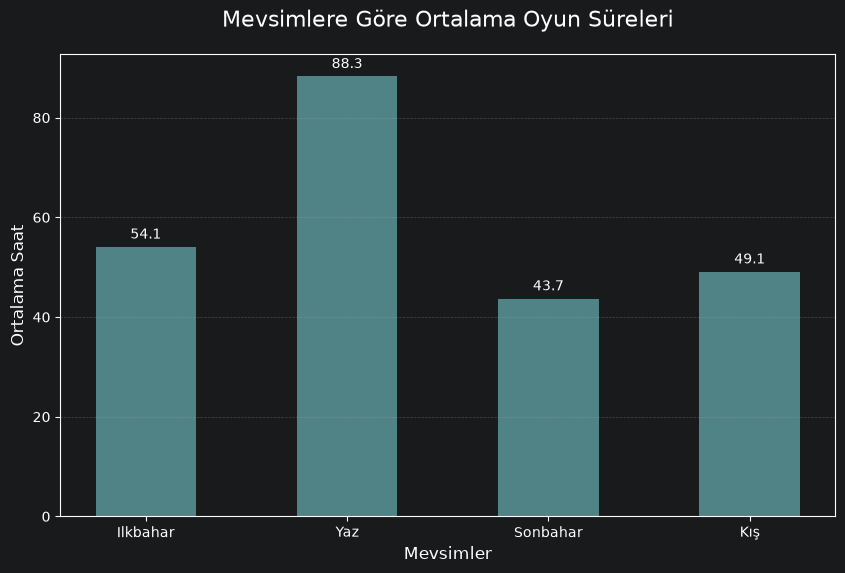

In [6]:
import matplotlib.pyplot as plt


mevsimler = ['Ilkbahar', 'Yaz', 'Sonbahar', 'Kış']


mevsimlik_ortalamalar = [
    df['Ilkbahar_Saati'].mean(),
    df['Yaz_Saati'].mean(),
    df['Sonbahar_Saati'].mean(),
    df['Kis_Saati'].mean()
]

plt.figure(figsize=(10, 6))


bars = plt.bar(mevsimler, mevsimlik_ortalamalar, color='#5F9EA0', alpha=0.8, width=0.5)


plt.title('Mevsimlere Göre Ortalama Oyun Süreleri', fontsize=16, pad=20)
plt.ylabel('Ortalama Saat', fontsize=12)
plt.xlabel('Mevsimler', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 1), ha='center', va='bottom', fontsize=10)

plt.show()

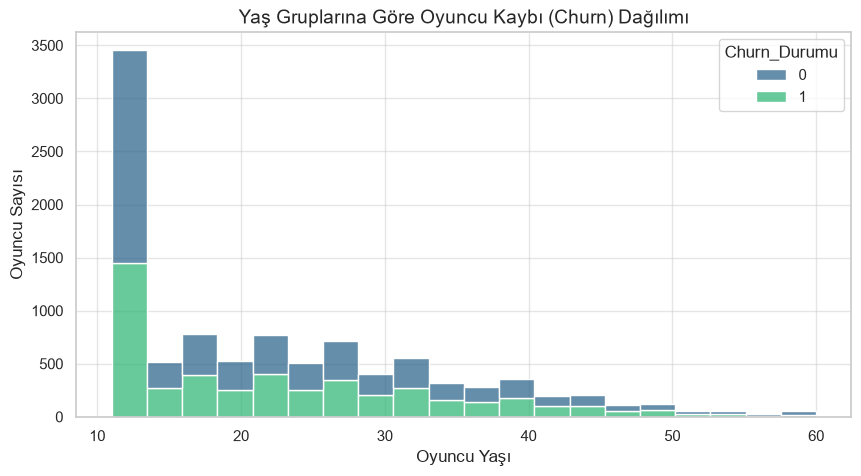

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/my_dataset.csv")
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='Yas', hue='Churn_Durumu',
             multiple='stack',
             palette='viridis',
             bins=20)

plt.title('Yaş Gruplarına Göre Oyuncu Kaybı (Churn) Dağılımı', fontsize=14)
plt.xlabel('Oyuncu Yaşı')
plt.ylabel('Oyuncu Sayısı')
plt.show()

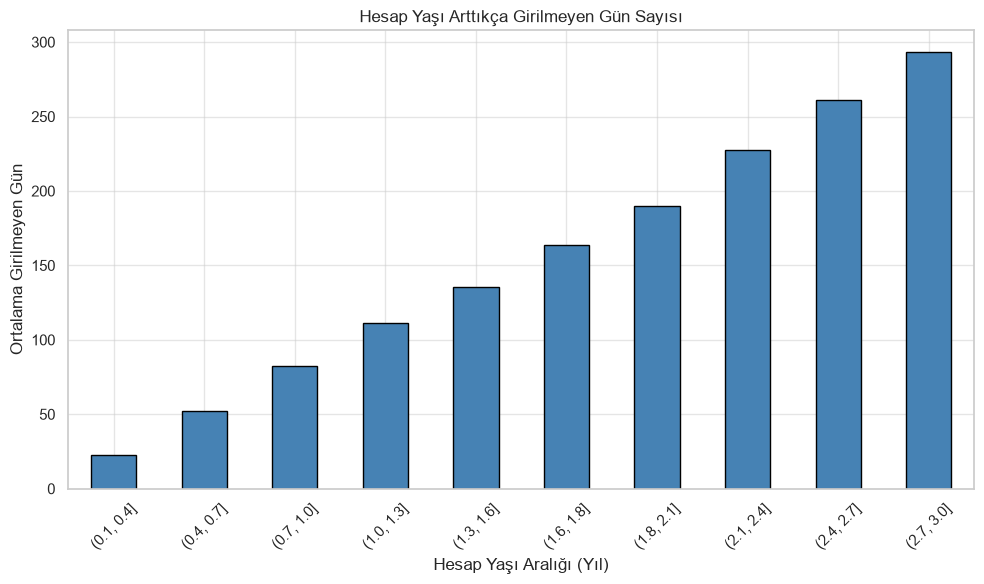

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/my_dataset.csv")

df["Son_Giris"] = pd.to_datetime(df["Son_Giris"])
bugun = pd.Timestamp.now()
df["Girilmeyen_Gun"] = (bugun - df["Son_Giris"]).dt.days

df["Hesap_Yasi_Grup"] = pd.cut(df["Hesap_Yasi"], bins=10, precision=0)
grup_ortalama = df.groupby("Hesap_Yasi_Grup", observed=True)["Girilmeyen_Gun"].mean()


plt.figure(figsize=(10, 6))
grup_ortalama.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Hesap Yaşı Arttıkça Girilmeyen Gün Sayısı")
plt.xlabel("Hesap Yaşı Aralığı (Yıl)")
plt.ylabel("Ortalama Girilmeyen Gün")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
